In [1]:
wiki_dump_path = "C:\\Users\\koncs\\Master\\Master_second_semester\\NLP\\enwiki-20061130-pages-articles.xml.bz2"

In [29]:
import bz2
import mwparserfromhell
import xml.etree.ElementTree as ET

In [3]:
# opening the compressed file - we don`t uncompress because it requires a lot of space
source = bz2.BZ2File(wiki_dump_path)

In [4]:
pages = ET.iterparse(source, events=('start', 'end'))
pages = iter(pages)

\*=_=\*=_=\* is the splitter between title and text in links

In [ ]:
import json
MIN_BYTE_SIZE = 1024
with open('processed_wiki4.jsonl', 'a', encoding='utf-8') as f:
    for event, elem in pages:
        tag = elem.tag.split('}')[-1]
        if event == "end" and tag == "page":
            title = elem.find('.//{*}title').text
            revision = elem.find('{*}revision')
            text = revision.find('{*}text').text
            if text and len(text) >= MIN_BYTE_SIZE:
                    parsed_text = mwparserfromhell.parse(text)
                    cleaned_text = str(parsed_text.strip_code())
                    link_titles = [f"{str(l.title)}*=_=*=_=*{str(l.text)}" if l.text else f"{str(l.title)}" for l in parsed_text.filter_wikilinks()]
                    page_dict = {
                        "title": title,
                        "text": cleaned_text,
                        "links": link_titles
                    }
                    f.write(json.dumps(page_dict, ensure_ascii=False) + "\n")
            elem.clear()


{{Politics of Angola}}
'''Politics of Angola''' takes place in a framework of a [[presidential system|presidential]] [[republic]], whereby the [[President of Angola]] is both [[head of state]] and [[head of government]], and of a pluriform multi-party system. [[Executive power]] is exercised by the government. [[Legislative power]] is vested in both the [[government]] and parliament. [[Angola]] changed from a [[Single-party state|one-party]] [[Marxist]]-[[Leninist]] system ruled by the [[Popular Movement for the Liberation of Angola|MPLA]] to a formal multiparty democracy following the 1992 elections. President [[José Eduardo dos Santos|dos Santos]] won the first round election with more than 49% of the vote to [[Jonas Savimbi]]'s 40%. A runoff never has taken place. The subsequent renewal of civil war and collapse of the [[Lusaka Protocol]] have left much of this process stillborn, but democratic forms exist, notably the [[National Assembly of Angola|National Assembly]].
Currently, po

In [241]:
# construct keyword vocabulary
import json 

vocabulary = {}
with open('processed_wiki.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        links = data.get("links", [])
        for link in links:
            if link in vocabulary:
                    vocabulary[link]+= 1
            else:
                    vocabulary[link] = 1

In [243]:
len(vocabulary)

13560948

In [244]:
new_voc = []
for keyword, frequency in vocabulary.items():
    if frequency >= 5:
        new_voc.append(keyword)

In [245]:
len(new_voc)

1276900

In [246]:
print(new_voc[:4000])


['Live album', 'Fatboy Slim', 'Electronica', 'Skint Records', 'All Music Guide', 'Robert Christgau', 'Rolling Stone', 'Q magazine*=_=*=_=*Q', 'Better Living Through Chemistry (album)*=_=*=_=*Better Living Through Chemistry', "You've Come a Long Way, Baby", 'Brighton', 'England', 'Incredible Bongo Band', 'Jungle Brothers', 'Hardknox', 'Category:1998 albums', 'Category:Fatboy Slim albums', 'Buddhism', 'History of Buddhism', 'Dharmic religions', 'Timeline of Buddhism', 'Buddhist councils', 'Four Noble Truths', 'Noble Eightfold Path', 'Three Jewels', 'Three marks of existence', 'Dharma (Buddhism)*=_=*=_=*Dharma', 'Shunyata', 'Pratitya-samutpada', 'Gautama Buddha', 'Bodhisattva', 'Buddhist meditation*=_=*=_=*Meditation', 'Tibetan Buddhism*=_=*=_=*Tibet', 'Schools of Buddhism', 'Theravada*=_=*=_=*Theravāda', 'Mahayana*=_=*=_=*Mahāyāna', 'Vajrayana*=_=*=_=*Vajrayāna', 'Pali Canon', 'Mahayana Sutras', 'Category:Religion navigational boxes*=_=*=_=*{{PAGENAME}}', 'Category:Buddhism templates*=_=

In [248]:
# add every title to the vocabulary which are not there yet

new_voc_set = set(new_voc) 

with open('processed_wiki.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        title = data.get("title", "")
        
        if title not in new_voc_set:
            new_voc_set.add(title)

new_voc = list(new_voc_set)

In [249]:
len(set(new_voc))

1998679

In [250]:
import re
def clean_keyword(keyword):
    keyword = keyword.replace('\n', ' ').replace('\r', ' ')
    keyword = re.sub(r'\s+', ' ', keyword).strip()
    return keyword

In [251]:
cleaned_keywords = []
for keyword in new_voc:
    keyword = clean_keyword(keyword)
    cleaned_keywords.append(keyword)

In [252]:
with open('vocabular.txt', 'w', encoding='utf-8') as voc_f:
        for keyword in cleaned_keywords:
                voc_f.write(f"{keyword}\n")

In [253]:
len(set(cleaned_keywords))

1998116

1227183 documents (after filtering out the ones smaller than 1024 bytes)

1998116 keyphrases in the vocabulary (1227183 title + their surface forms (with >5 frequency))

CLEAN ARTICLES

====TEXT====

x See also x

x External links x

x Further reading x

x References x

x Notes x

x Category x

In [26]:
num_of_lines = 0
with open('processed_wiki.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        num_of_lines+=1
print(num_of_lines)

1227183


In [ ]:
# select out randomly 100 documents to do the wikification and evaluate then

import json
import random

random_idxs = random.sample(range(num_of_lines), 100)
i = 0
choosen_docs = []
with open('cleaned_data4.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if i in random_idxs:
            line = json.loads(line)
            choosen_docs.append(line)
        i+=1

In [31]:
with open('docs_to_evaluate4.jsonl', 'w', encoding='utf-8') as f:
        for idx, doc in enumerate(choosen_docs):
            line = {"idx": random_idxs[idx], "title":doc["title"], "text": doc["cleaned_text"], "ngrams": doc["valid_ngrams"], "links": doc["links"]}
            f.write(json.dumps(line, ensure_ascii=False) + "\n")

CANDIDATE EXTRACTION

In [12]:
# read in new_voc
import json 

new_voc = []
with open('vocabular.txt', 'r', encoding='utf-8') as f:
        for line in f:
            # line.strip() removes \n, \r, \t, and spaces from both ends
            clean_line = line.strip()
            
            if not clean_line:
                continue
            
            new_voc.append(clean_line)
            
        

In [13]:
# handle when the text of a link is not the same as the title
vocabular_of_keywords = []
titles_of_text = {}
counter = 0
for keyword in new_voc:
    if "*=_=*=_=*" in keyword:
        counter+=1
        title, text = keyword.split("*=_=*=_=*")
        vocabular_of_keywords.append(text)
        if text in titles_of_text:
            titles_of_text[text].append(title)
        else:
            titles_of_text[text] = [title]
    else:
        vocabular_of_keywords.append(keyword)

In [14]:
# handle case if a keyword is also a title and a surface form

titles = []
with open('processed_wiki.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        title = data.get("title", "")
        titles.append(title)

titles_set = set(titles)

for keyword in titles_of_text:
    if keyword in titles_set:
            titles_of_text[keyword].append(keyword)

In [476]:
# save titles for later
import numpy as np
np.save('titles_of_wiki_docs.npy', titles)

In [61]:
# find out how many words has the longest keyword
import nltk
from nltk import tokenize

keyword_lengths = {}
num_of_tokens_of_longest_keyword = 0 
for keyword in vocabular_of_keywords:
    tokens = tokenize.word_tokenize(keyword)
    num_of_tokens = len(tokens)
    if num_of_tokens in keyword_lengths:
        keyword_lengths[num_of_tokens] +=1
    else:
        keyword_lengths[num_of_tokens] = 1
    if num_of_tokens > num_of_tokens_of_longest_keyword:
        num_of_tokens_of_longest_keyword = num_of_tokens
        if num_of_tokens > 180:
            print(keyword)
print(num_of_tokens_of_longest_keyword)
print(keyword_lengths)

<font face="impact" color="480652">G</font><font face="impact" color="#5D007A">r</font><font face="impact" color="#7E1D9C">o</font><font face="impact" color="#A545C2">n</font><font face="impact" color="#DF89F9">k</font><font face="impact" color="#F0CDFB">m</font><font face="impact" color="#CDFBEA">e</font><font face="impact" color="#77F7C8">i</font><font face="impact" color="#45D9A2">s</font><font face="impact" color="#12A36E">t</font><font face="impact" color="#058153">e</font><font face="impact" color="#053402">r</font>
191
{6: 113388, 2: 646923, 1: 447953, 4: 192180, 5: 156242, 10: 10193, 8: 29629, 11: 5755, 3: 305424, 7: 61285, 9: 19669, 12: 3369, 13: 1889, 18: 275, 15: 811, 14: 1317, 22: 124, 19: 182, 16: 442, 23: 99, 25: 65, 21: 105, 20: 153, 17: 337, 56: 4, 0: 152, 58: 2, 33: 34, 24: 80, 32: 22, 31: 27, 39: 18, 36: 17, 28: 46, 26: 44, 44: 14, 99: 2, 51: 7, 35: 17, 46: 10, 34: 32, 30: 47, 48: 17, 67: 2, 43: 10, 68: 2, 60: 4, 63: 5, 42: 10, 100: 1, 47: 4, 27: 34, 29: 24, 62: 1, 10

0    447953
1    646923
2    305424
3    192180
4    156242
5    247305
6      2375
7        87
8        34
Name: Frequency, dtype: int64


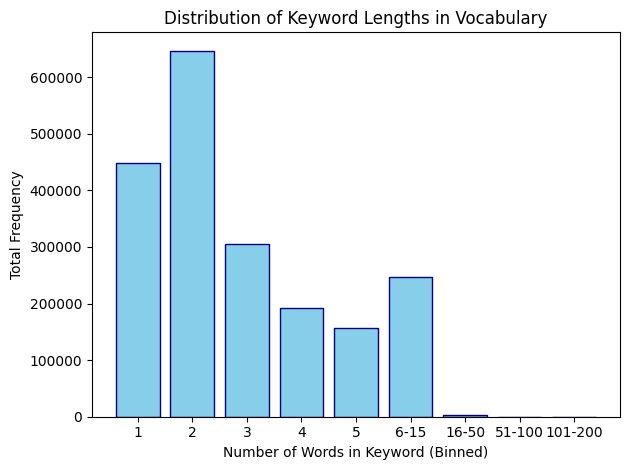

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(list(keyword_lengths.items()), columns=['Word Count', 'Frequency'])


bins = [0, 1, 2, 3, 4, 5, 15, 50, 100, 200]
labels = ['1', '2', '3', '4', '5', '6-15', '16-50', '51-100', '101-200']

df['Bin'] = pd.cut(df['Word Count'], bins=bins, labels=labels)

binned_df = df.groupby('Bin', observed=False)['Frequency'].sum().reset_index()
print(binned_df['Frequency'])
plt.bar(binned_df['Bin'], binned_df['Frequency'], color='skyblue', edgecolor='navy')

plt.xlabel('Number of Words in Keyword (Binned)')
plt.ylabel('Total Frequency')
plt.title('Distribution of Keyword Lengths in Vocabulary')

# Save and export
plt.tight_layout()
plt.savefig('binned_keyword_lengths.png')

In [17]:
# read in saved articles for evaluation
import json 

choosen_articles = []
with open('docs_to_evaluate4.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        choosen_articles.append(data)

In [18]:
# example
for ngram in choosen_articles[0]["ngrams"]:
    print(ngram)

of
Metohija
Kosovo
.
The
largest
cities
are
Metohija
(
Serbian
:
,
Albanian
:
i
)
,
Metohia
,
is
a
basin
and
the
name
of
the
region
covering
the
south-western
part
of
Serbian
southern
province
Kosovo
.
Name
The
name
Metohija
“
land
owned
and
governed
by
monasteries
”
or
“
church
land
”
.
The
term
is
of
Greek
origin
and
from
the
medieval
name
for
the
monastery
land
to
Orthodox
monasteries
by
the
Serbian
.
In
Albanian
the
area
is
called
i
and
the
plateau
of
Duke
,
named
named after
the
the land
land
of
an
Albanian
medieval
nobleman
.
Serbs
,
,
that
Metohija
is
one
of
two
parts
of
the
province
Kosovo
Kosovo and Metohija
and
Metohija
,
the
name
Kosovo
is
used
for
the
whole
region
.
Common
in
Serbia
,
Montenegro
and
Republika
Republika Srpska
is
the
form
.
The
full
full name
name
was
official
1974
it
was
abolished
by
the
communist
communist regime
regime
to
the
religious
meaning
,
it
was
still
used
the
Serbian
population
and
in
1989
by
the
Serbian
government
.
Geography
Metohija
is
23
kilom

In [19]:
#EXAMPLE

print(len(choosen_articles[0]["ngrams"]))
print(set(choosen_articles[0]["ngrams"]))
print(len(set(choosen_articles[0]["ngrams"])))

721
{'Islam', 'part', 'In', 'sea level', 'Slavic', 'level', 'Autonomous', 'II', 'Orthodox Christianity', 'north', 'division', 'between', 'Ottomans', 'Albania', 'House', 'still', 'species', 'Tsar', '1459', 'Kingdom of Montenegro', 'irrigation', 'Balkan', '-', 'Serbs', 'for', 'chestnut', '1944', 'arable', 'Grand', 'Province', 'Democratic Federal Yugoslavia', 'fields', 'number', 'well', 'used', 'that', 'one', 'under', 'World War', 'Prokletije', 'this', 'fertile', 'term', 'It', '1345', 'form', 'medieval', 'centuries', 'Serbia', 'principal', 'Duke', 'Name', '10th century', 'meaning', 'many', 'Control', 'The Kingdom', 'conquered', 'not', 'capital', 'causes', 'the land', 'cities', 'Orthodox', 'Federal', 'climate', 'dominant', 'First World', 'or', 'area', 'being', 'plateau', 'Albanians', 'Bulgarian', 'an', 'influence', 'covering', 'monastery', 'Cities', 'largest', 'be', 'Allies', 'region', 'Autonomous Province', ',', 'Mokra', 'the Allies', '12th', 'which', 'forces', 'Princes', 'and', 'parts', 

RANKING KEYWORDS

1. TF.IDF : the number of occurrences of a term
in a given document multiplied with the (often log
smoothed) inverse of the number of documents where
the term appears



In [20]:
import re


ngram_freq_in_doc = [{} for _ in range(len(choosen_articles))]
for idx, doc in enumerate(choosen_articles):
    text = doc["text"]
    for ngram in doc["ngrams"]:
        # find out how many times occurs the term in the doc with the help of regex
        safe_ngram = re.escape(ngram)
        freq_of_term_in_doc = len(re.findall(safe_ngram, text))
        # print(f"{ngram}: {freq_of_term_in_doc}")
        ngram_freq_in_doc[idx][ngram] = freq_of_term_in_doc 

In [21]:
print(ngram_freq_in_doc)

[{'of': 46, 'Metohija': 20, 'Kosovo': 9, '.': 32, 'The': 13, 'largest': 2, 'cities': 2, 'are': 6, '(': 1, 'Serbian': 9, ':': 3, ',': 36, 'Albanian': 4, 'i': 282, ')': 2, 'Metohia': 1, 'is': 27, 'a': 289, 'basin': 1, 'and': 33, 'the': 69, 'name': 6, 'region': 7, 'covering': 1, 'south-western': 1, 'part': 4, 'southern': 1, 'province': 2, 'Name': 1, '“': 2, 'land': 5, 'owned': 1, 'governed': 1, 'by': 14, 'monasteries': 2, '”': 2, 'or': 32, 'church': 1, 'term': 1, 'Greek': 1, 'origin': 1, 'from': 7, 'medieval': 2, 'for': 10, 'monastery': 1, 'to': 35, 'Orthodox': 2, 'In': 2, 'area': 4, 'called': 1, 'plateau': 1, 'Duke': 1, 'named': 1, 'named after': 1, 'the land': 1, 'an': 80, 'nobleman': 1, 'Serbs': 4, 'that': 2, 'one': 1, 'two': 2, 'parts': 1, 'Kosovo and Metohija': 1, 'used': 2, 'whole': 1, 'Common': 1, 'in': 68, 'Serbia': 15, 'Montenegro': 4, 'Republika': 1, 'Republika Srpska': 1, 'form': 4, 'full': 1, 'full name': 1, 'was': 14, 'official': 2, '1974': 1, 'it': 31, 'abolished': 1, 'commu

In [22]:
ngrams_merged_in_choosen_articles = []
for doc in choosen_articles:
    for ngram in doc["ngrams"]:
        ngrams_merged_in_choosen_articles.append(ngram)
ngrams_merged_in_choosen_articles = set(ngrams_merged_in_choosen_articles)

In [23]:
# EXAMPLE
len(ngrams_merged_in_choosen_articles)

9954

In [32]:
# go through each article and check the presence of the ngrams

#init dict
freq_of_terms_in_overall_docs = {}
for ngram in ngrams_merged_in_choosen_articles:
    freq_of_terms_in_overall_docs[ngram] = 0

i = 0
with open('cleaned_data4.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        i += 1
        data = json.loads(line)
        text = data.get("cleaned_text", "")
        ngrams = set(data.get("valid_ngrams", []))
        for ngram in ngrams:
            if ngram in freq_of_terms_in_overall_docs:
                freq_of_terms_in_overall_docs[ngram] += 1      
        if i % 10000==0:
            print(i)        

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000
1010000
1020000
1030000
1040000
1050000
1060000
1070000
1080000
1090000
1100000
1110000
1120000
1130000
1140000
1150000
1160000
1170000
1180000
1190000
1200000
1210000
1220000


In [25]:
# calculate the tfidf value of each ngram in the choosen articles
import math

tfidfs = []
N = num_of_lines
for idx, doc in enumerate(choosen_articles):
    tfidfs.append({})
    for ngram in doc["ngrams"]:
        local_freq = ngram_freq_in_doc[idx][ngram]
        global_freq = freq_of_terms_in_overall_docs[ngram]
        tfidfs[idx][ngram] = local_freq * math.log(N / global_freq)

NameError: name 'num_of_lines' is not defined

In [ ]:
# EXAMPLE
import numpy as np
k = np.array(list(tfidfs[0].keys()))
v = np.array(list(tfidfs[0].values()))
sorted_indexes = np.argsort(v)[::-1]  # descending order
sorted= {k[idx]:v[idx] for idx in sorted_indexes }
for k,v in sorted.items():
    print(f"{k}: {v}")

i: 1130.9340037223506
Metohija: 194.0548748658024
Serbia: 81.20345488473883
Kosovo: 57.99259880868052
Serbian: 50.77036770785843
an: 37.21740872344445
Albania: 30.597976219042124
Serbs: 26.41060581764754
Albanian: 26.01301852888843
or: 25.614794109085206
a: 24.78805963277797
Montenegro: 24.511119253224305
Kingdom: 22.074722735147187
The Kingdom: 21.266280153680924
it: 21.191681171814842
region: 21.110726198033223
Rascia: 19.601448303300643
Yugoslav: 19.442019082576195
conquered: 15.760577577227739
rest: 15.524807954784626
Mediterranean: 14.982164209570714
south: 14.62169068167915
rule: 14.326738838717409
migrations: 14.296207510974885
meters: 13.708846604387206
Principality: 13.671205408218228
land: 13.070116913330756
restored: 13.043004128770416
Princes: 12.628137773253707
monasteries: 12.583632153970774
fauna: 12.572221106996247
flora: 12.528073025756623
Viyalet of Kosovo: 12.410793944392328
west: 12.405474830103964
Mokra Gora: 12.074321707771116
at: 11.95690802300394
Prokletije: 11.

In [ ]:
# select the keywords based on tfidf
import numpy as np
from nltk import tokenize

keywords_of_choosen_articles_tfidf = {}
for idx_of_doc, doc in enumerate(choosen_articles):
    # sort keywords by their tfidf value
    k = np.array(list(tfidfs[idx_of_doc].keys()))
    v = np.array(list(tfidfs[idx_of_doc].values()))
    sorted_indexes = np.argsort(v)[::-1]  # descending order
    sorted_keys = k[sorted_indexes]

    # the number of keywords = number of terms in the article * 6/100
    terms_of_doc = len(tokenize.word_tokenize(doc["text"]))
    num_of_keywords = int(terms_of_doc*6/100)

    current_num_of_keywords = len(tfidfs[idx_of_doc])
    if num_of_keywords < current_num_of_keywords:
        keywords_of_choosen_articles_tfidf[idx_of_doc] = set(sorted_keys[:num_of_keywords])
    else:
        keywords_of_choosen_articles_tfidf[idx_of_doc] = set(sorted_keys)

In [442]:
# EXAMPLE
for keyword in keywords_of_choosen_articles_tfidf[0]:
    print(keyword)

an
Empire
Rascia
The Kingdom
History of Kosovo
region
Kosovo
Mokra Gora
at
Viyalet of Kosovo
conquered
west
fauna
as
Princes
Serbia
a
Albania
land
Yugoslav
monasteries
House of Vojislavljević
Principality
Serbian
migrations
Šar mountain
south
Prokletije
restored
i
House of Nemanjić
it
Mediterranean
Kingdom
or
Serbs
out
Metohija
rest
Democratic Federal Yugoslavia
flora
meters
House of Vlastimirović
Montenegro
rule
Albanian


In [47]:
# get the links of docs
links_of_choosen_docs = {}
with open('docs_to_evaluate4.jsonl', 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            data = json.loads(line)
            links = set(data.get("links", []))
            links_of_choosen_docs[idx] = links

In [48]:
links_of_choosen_docs[0]

{'1974',
 '1989',
 'Albanian language*=_=*=_=*Albanian',
 'Albanians',
 'Allies of World War II*=_=*=_=*Allies',
 'Austro-Hungarian',
 'Axis Powers*=_=*=_=*Axis',
 'Byzantine Empire',
 'Category:Geography of Kosovo',
 'Central Powers',
 'Chetniks',
 'Desnik*=_=*=_=*Dostinik',
 'Dečani',
 'Drenica',
 'Drin River*=_=*=_=*White Drim',
 'Eastern Orthodox Church*=_=*=_=*Orthodox Christianity',
 'First Balkan War*=_=*=_=*Balkan War',
 'First World War',
 'Greater Albania*=_=*=_=*Fascist Albania',
 'Greek language*=_=*=_=*Greek',
 'History of Kosovo',
 'History of Kosovo*=_=*=_=*Autonomous Province of Kosmet',
 'History of Montenegro*=_=*=_=*Kingdom of Montenegro',
 'History of Serbia*=_=*=_=*Kingdom of Serbia',
 'History of Serbia*=_=*=_=*Kingdom of the Serbs',
 'House of Nemanjić',
 'House of Vlastimirović',
 'House of Vojislavljević',
 'Image:Map2344.png*=_=*=_=*thumb|right|299px|Map of Metohija within Kosovo. The largest cities are also shown',
 'Islam',
 'Istok',
 'Kingdom of Serbs, Croa

In [44]:
# code found here: https://sila-kazan0626.medium.com/levenshtein-distance-and-cosine-similarity-in-text-comparison-a7adf8134125
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def cosine_similarity_of_two_string(art1, art2):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([art1, art2])
    cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    return cosine_sim_matrix[0][1]
    

In [390]:
# get every needed doc text for cosine similarity

titles_of_docs_to_search = []
for keyword in titles_of_text:
    for title in titles_of_text[keyword]:
        if title in titles_set:
            titles_of_docs_to_search.append(title)

titles_of_docs_to_search = set(titles_of_docs_to_search)
doc_text_for_cos_sim = {}
with open('cleaned_data4.jsonl', 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            data = json.loads(line)
            title = data.get("title", "")
            if title in titles_of_docs_to_search:
                text = data.get("cleaned_text", "")
                doc_text_for_cos_sim[title] = text

In [474]:
# save the docs for later
with open('docs_for_check_cos_sim.json', 'w') as f:
    json.dump(doc_text_for_cos_sim, f, indent=4)

In [43]:
with open('C:\\Users\\koncs\\Master\\Master_second_semester\\NLP\\Labs\\nlp_01\\nlp02\\docs_for_check_cos_sim.json', 'r') as f:
    doc_text_for_cos_sim = json.load(f)

In [41]:
# Go through choosen keywords, select and apend to them the suitable title of the keyword based on cosine similarity(if exists)
def complete_keywords(keywords_of_docs):
    completed_keywords_of_choosen_articles = {}
    for idx in range(len(choosen_articles)):
        print(idx)
        completed_keywords_of_choosen_articles[idx] = []
        for keyword in keywords_of_docs[idx]:
            if keyword in titles_of_text:
                possible_titles = titles_of_text[keyword]
                text_of_doc = choosen_articles[idx]["text"]
                cos_sim_with_doc = {}
                for t in possible_titles:
                    # if there is no doc in my dataset with this title --> skip
                    if t not in titles:
                        continue
                    # find the text of the article with the given title
                    text_of_possible_doc = doc_text_for_cos_sim[t]
                    cos_sim = cosine_similarity_of_two_string(text_of_doc, text_of_possible_doc)
                    cos_sim_with_doc[t] = cos_sim
                
                # if no doc find by title then add the ngram itself
                if len(cos_sim_with_doc) == 0:
                    completed_keywords_of_choosen_articles[idx].append(f"{keyword}")
                else:
                    # get the title of doc with max cos sim
                    doc_title_by_cos_sim = max(cos_sim_with_doc, key=cos_sim_with_doc.get)
                    if doc_title_by_cos_sim == keyword: 
                        completed_keywords_of_choosen_articles[idx].append(f"{keyword}")
                    else:
                        completed_keywords_of_choosen_articles[idx].append(f"{doc_title_by_cos_sim}*=_=**=_=*{keyword}" )
            else:
                completed_keywords_of_choosen_articles[idx].append(f"{keyword}")
    return completed_keywords_of_choosen_articles


In [ ]:
completed_keywords_of_choosen_articles_tfidf = complete_keywords(keywords_of_choosen_articles_tfidf)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [444]:
completed_keywords_of_choosen_articles_tfidf

{0: ['an',
  'The Empire (Warhammer)*=_=**=_=*Empire',
  'Raci*=_=**=_=*Rascia',
  'The Kingdom (comic book)*=_=**=_=*The Kingdom',
  'History of Kosovo',
  'Regions of England*=_=**=_=*region',
  'Kosovo War*=_=**=_=*Kosovo',
  'Mokra Gora',
  'at',
  'Viyalet of Kosovo',
  'conquered',
  'Western Roman Empire*=_=**=_=*west',
  'Fauna of Azerbaijan*=_=**=_=*fauna',
  'As (coin)*=_=**=_=*as',
  'List of rulers of Wallachia*=_=**=_=*Princes',
  'Serbia',
  'Away goals rule*=_=**=_=*a',
  'Albania',
  'Land of Israel*=_=**=_=*land',
  'Yugoslavia*=_=**=_=*Yugoslav',
  'Monastery*=_=**=_=*monasteries',
  'House of Vojislavljević',
  'Principality',
  'Serbia*=_=**=_=*Serbian',
  'migrations',
  'Šar mountain',
  'Southern United States*=_=**=_=*south',
  'Prokletije',
  'English Restoration*=_=**=_=*restored',
  'I (TV network)*=_=**=_=*i',
  'House of Nemanjić',
  'it',
  'Mediterranean Sea*=_=**=_=*Mediterranean',
  'Monarchy*=_=**=_=*Kingdom',
  'Or (heraldry)*=_=**=_=*or',
  'Serbia*=

In [445]:
print(len(keywords_of_choosen_articles_tfidf[0]))
print(keywords_of_choosen_articles_tfidf[0])
print(len(completed_keywords_of_choosen_articles_tfidf[0]))
print(completed_keywords_of_choosen_articles_tfidf[0])

46
{np.str_('an'), np.str_('Empire'), np.str_('Rascia'), np.str_('The Kingdom'), np.str_('History of Kosovo'), np.str_('region'), np.str_('Kosovo'), np.str_('Mokra Gora'), np.str_('at'), np.str_('Viyalet of Kosovo'), np.str_('conquered'), np.str_('west'), np.str_('fauna'), np.str_('as'), np.str_('Princes'), np.str_('Serbia'), np.str_('a'), np.str_('Albania'), np.str_('land'), np.str_('Yugoslav'), np.str_('monasteries'), np.str_('House of Vojislavljević'), np.str_('Principality'), np.str_('Serbian'), np.str_('migrations'), np.str_('Šar mountain'), np.str_('south'), np.str_('Prokletije'), np.str_('restored'), np.str_('i'), np.str_('House of Nemanjić'), np.str_('it'), np.str_('Mediterranean'), np.str_('Kingdom'), np.str_('or'), np.str_('Serbs'), np.str_('out'), np.str_('Metohija'), np.str_('rest'), np.str_('Democratic Federal Yugoslavia'), np.str_('flora'), np.str_('meters'), np.str_('House of Vlastimirović'), np.str_('Montenegro'), np.str_('rule'), np.str_('Albanian')}
46
['an', 'The Emp

Precision: is calculated as
the number of correctly identified keywords divided by the
total number of keywords proposed by the system

Recall: is
defined as the number of correct keywords divided by the
total number of keywords in the original document

F-Measure: is the harmonic mean of the precision and recall

In [33]:
# evaluate
def evaluate(identified_keywords, ground_truth_keywords, num_of_articles):
    num_of_correctly_identified_keywords = {}
    for i in range(num_of_articles):
        num_of_correctly_identified_keywords[i] = 0
        for keyword in identified_keywords[i]:
            if keyword in ground_truth_keywords[i]:
                num_of_correctly_identified_keywords[i] += 1

    total_correct = 0
    total_predicted_keyword = 0
    total_keyword = 0
    for i in range(num_of_articles):
        total_correct += num_of_correctly_identified_keywords[i]
        total_predicted_keyword += len(identified_keywords[i])
        total_keyword += len(ground_truth_keywords[i])

    precision = total_correct/total_predicted_keyword
    recall = total_correct/total_keyword
    f1 = 2/((1/precision) + (1/recall))
    return precision, recall, f1


In [469]:
precision_tfidf, recall_tfidf, f1_tfidf = evaluate(completed_keywords_of_choosen_articles_tfidf, links_of_choosen_docs, len(choosen_articles))

print(f"Precision: {precision_tfidf}")
print(f"Precision: {recall_tfidf}")
print(f"F1 measure: {f1_tfidf}")

Precision: 0.12994029001990332
Precision: 0.08570892723180795
F1 measure: 0.10328850717595209





2. KEYPHRASES: the number of
documents where the term was already selected as a
keyword (count(Dkey)) divided by the total number
of documents where the term appeared (count(DW)). (This probability can be interpreted as “the more of
ten a term was selected as a keyword among its total
number of occurrences, the more likely it is that it will
be selected again”. )

In [35]:
# get the number of documents where the term was selected as a keyword

#init dict
freq_of_terms_in_overall_docs_as_keyword = {}
for ngram in ngrams_merged_in_choosen_articles:
    freq_of_terms_in_overall_docs_as_keyword[ngram] = 0

i = 0
with open('cleaned_data4.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        i += 1
        data = json.loads(line)
        links = set(data.get("links", []))
        for link in set(links):
            searched_token = link
            if "*=_=**=_=*" in link:
                link_title, link_text = link.split("*=_=**=_=*")
                searched_token = link_text
            if searched_token in freq_of_terms_in_overall_docs_as_keyword:
                freq_of_terms_in_overall_docs_as_keyword[link] += 1   
        if i % 10000==0:
            print(i)
        

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000
1010000
1020000
1030000
1040000
1050000
1060000
1070000
1080000
1090000
1100000
1110000
1120000
1130000
1140000
1150000
1160000
1170000
1180000
1190000
1200000
1210000
1220000


In [36]:
keyphrase_values = []
for idx, doc in enumerate(choosen_articles):
    keyphrase_values.append({})
    for ngram in doc["ngrams"]:
        keyphrase_values[idx][ngram] = freq_of_terms_in_overall_docs_as_keyword[ngram]/freq_of_terms_in_overall_docs[ngram]

In [37]:
# select the keywords based on keyphrase values
import numpy as np

keywords_of_choosen_articles_keyphrase = {}
for idx_of_doc, doc in enumerate(choosen_articles):
    # sort keywords by their keyphrase values
    k = np.array(list(keyphrase_values[idx_of_doc].keys()))
    v = np.array(list(keyphrase_values[idx_of_doc].values()))
    sorted_indexes = np.argsort(v)[::-1]  # descending order
    sorted_keys = k[sorted_indexes]

    # the number of keywords = number of terms in the article * 6/100
    terms_of_doc = len(tokenize.word_tokenize(doc["text"]))
    ideal_num_of_keywords = int(terms_of_doc*6/100)

    current_num_of_keywords = len(keyphrase_values[idx_of_doc])
    if ideal_num_of_keywords < current_num_of_keywords:
        keywords_of_choosen_articles_keyphrase[idx_of_doc] = sorted_keys[:ideal_num_of_keywords]
    else:
        keywords_of_choosen_articles_keyphrase[idx_of_doc] = k


In [45]:
completed_keywords_of_choosen_articles_keyphrase = complete_keywords(keywords_of_choosen_articles_keyphrase)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [57]:
precision_kp, recall_kp, f1_kp = evaluate(completed_keywords_of_choosen_articles_keyphrase, links_of_choosen_docs, len(choosen_articles))

print(f"Precision: {precision_kp}")
print(f"Recall: {recall_kp}")
print(f"F1 measure: {f1_kp}")

Precision: 0.3357975547341484
Recall: 0.22149287321830458
F1 measure: 0.2669228161374167


TFIDF:

    Precision: 0.12994029001990332

    Precision: 0.08570892723180795

    F1 measure: 0.10328850717595209



KEYPHRASE:

    Precision: 0.3357975547341484

    Recall: 0.22149287321830458

    F1 measure: 0.2669228161374167

When I kept all the keywords found in the articles, the recall was 0.26, but the precision was very low at 0.06.